## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di esplorare, pulire e comprendere l'andamento temporale e spaziale dei crimini, applicando tecniche di **analisi di serie temporali e forecasting**, per prevedere l'evoluzione dei fenomeni criminali in determinati distretti o periodi.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, statsmodels, numpy, pmdarima e scikit-learn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione predittiva**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.


In [1]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Import del dataset**

Iniziamo l'analisi importanto il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Successivamente, verranno visualizzate le informazioni generali sulla struttura del dataset per comprenderne la composizione e la qualità dei dati disponibili.

In [2]:
import pandas as pd

file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

# Mostra le informazioni di base del DataFrame
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285807 entries, 0 to 285806
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CrimeDate        285807 non-null  object 
 1   CrimeTime        285807 non-null  object 
 2   CrimeCode        285807 non-null  object 
 3   Location         284184 non-null  object 
 4   Description      285807 non-null  object 
 5   Inside/Outside   281611 non-null  object 
 6   Weapon           97396 non-null   object 
 7   Post             285616 non-null  float64
 8   District         285749 non-null  object 
 9   Neighborhood     284106 non-null  object 
 10  Location 1       284188 non-null  object 
 11  Total Incidents  285807 non-null  int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 26.2+ MB


## **Descrizione del dataset**

Il dataset analizzato contiene **285.807 osservazioni** e **12 colonne**, ciascuna delle quali descrive un aspetto relativo a un singolo evento criminale registrato nella città di Baltimora.  
I dati coprono diverse dimensioni temporali, spaziali e categoriali, rendendoli adatti per analisi di tipo descrittivo, predittivo e temporale.

### **Struttura delle colonne**
| Colonna | Tipo | Descrizione |
|----------|------|-------------|
| **CrimeDate** | `object` | Data in cui il crimine è stato registrato. |
| **CrimeTime** | `object` | Ora dell’evento. |
| **CrimeCode** | `object` | Codice identificativo del tipo di reato. |
| **Location** | `object` | Indirizzo o descrizione del luogo in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Description** | `object` | Descrizione testuale del tipo di crimine (es. “ROBBERY”, “ASSAULT”). |
| **Inside/Outside** | `object` | Indica se il crimine è avvenuto all’interno (“Inside”) o all’esterno (“Outside”). Alcuni valori mancanti (≈1,5%). |
| **Weapon** | `object` | Tipologia di arma utilizzata (es. “Firearm”, “Knife”). Alta percentuale di valori mancanti (~66%). |
| **Post** | `float64` | Numero del distretto di polizia (post) in cui è stato registrato il crimine. |
| **District** | `object` | Nome del distretto di polizia (es. “SOUTHERN”, “NORTHERN”). Pochi valori mancanti. |
| **Neighborhood** | `object` | Nome del quartiere di Baltimora in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Location 1** | `object` | Coordinate geografiche (latitudine, longitudine) in formato stringa. |
| **Total Incidents** | `int64` | Numero totale di incidenti registrati per quella specifica voce (spesso pari a 1). |

### **Considerazioni preliminari**
Il dataset è **abbastanza completo**, con una percentuale di valori nulli limitata in quasi tutte le colonne tranne **Weapon**, che richiede attenzione nella fase di pulizia.  
I dati sono **prevalentemente categoriali e temporali**, il che li rende adatti per un'applicazione di **modelli di forecasting** sul numero di incidenti; 


### **Pulizia e preparazione dei dati**

Per poter effettuare un'analisi efficace, sono necessarie alcune operazioni preliminari di **data cleaning** e **trasformazione**:

1. **Gestione dei valori mancanti**
   - Le colonne `Location`, `Inside/Outside`, `Weapon`, `District` e    `Neighborhood` presentano una certa quantità di valori nulli.
   - Si sostituiranno i valori con una categoria "Unknown".

2. **Creazione della colonna temporale unificata**
   - Le colonne `CrimeDate` e `CrimeTime` saranno unite in un'unica colonna `Datetime`:
     ```python
     crime_data['Datetime'] = pd.to_datetime(crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], errors='coerce')
     ```

   - Questa nuova variabile temporale consentirà di:
     - ordinare gli eventi nel tempo (`sort_values('Datetime')`);
     - effettuare analisi stagionali o giornaliere;
     - eseguire resampling (su base giornaliera o settimanale).

3. **Analisi temporale e aggregazione**
   - Per studiare l'evoluzione dei crimini nel tempo, il dataset sarà aggregato per periodo:
     ```python
     crime_time_series = crime_data.set_index('Datetime').resample('W')['Total Incidents'].sum()
     ```
    
   - Questa operazione consente di generare una serie temporale settimanale, utile per il **forecasting del numero di crimini**.

4. **Verifica e coerenza dei dati temporali**
   - Controllare che i dati siano ordinati e coerenti nel tempo:
     ```python
     crime_data = crime_data.sort_values('Datetime').reset_index(drop=True)
     ```

In [3]:
# ==========================
# 1️⃣ Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
# 2️⃣ Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)

# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
# 3️⃣ Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
# 4️⃣ Creazione della serie temporale aggregata (weekly)
# ==========================
crime_time_series = (
    crime_data
    .set_index('DateTime')
    .resample('W')['Total Incidents']
    .sum()
    .reset_index()
)

# ==========================
# 5️⃣ Output
# ==========================
print("\n=== Dimensione dataset pulito ===")
print(f"Serie temporale settimanale: {crime_time_series.shape}")

print("\n=== Esempio serie temporale settimanale ===")
print(crime_time_series.head(5).to_string(index=False))

# Mostra le statistiche descrittive della serie temporale
print("\n=== Statistiche descrittive della serie temporale settimanale ===")
print(crime_time_series.describe())



--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64

=== Dimensione dataset pulito ===
Serie temporale settimanale: (307, 2)

=== Esempio serie temporale settimanale ===
  DateTime  Total Incidents
2011-01-02              281
2011-01-09              800
2011-01-16              750
2011-01-23              804
2011-01-30              667

=== Statistiche descrittive della serie temporale settimanale ===
                  DateTime  Total Incidents
count                  307       307.000000
mean   2013-12-08 00:00:00       917.247557
min    2011-01-02 00:00:00       281.000000
25%    2012-06-20 12:00:00       851.000000
50%    2013-12-08 00:00:00       932.000000
75%    2015-05-27 12:00:00      1003.000000
max    2016-11-13 00:00:00      1114.000000
std                    NaN       116.174862


## **Analisi esplorativa del dataset**

Si effettuerà una prima analisi visiva del dataset graficando l'andamento della serie temporale dei crimini a Baltimora, in modo tale da poter avanzare una prima ipotesi sulla stazionarietà della serie.

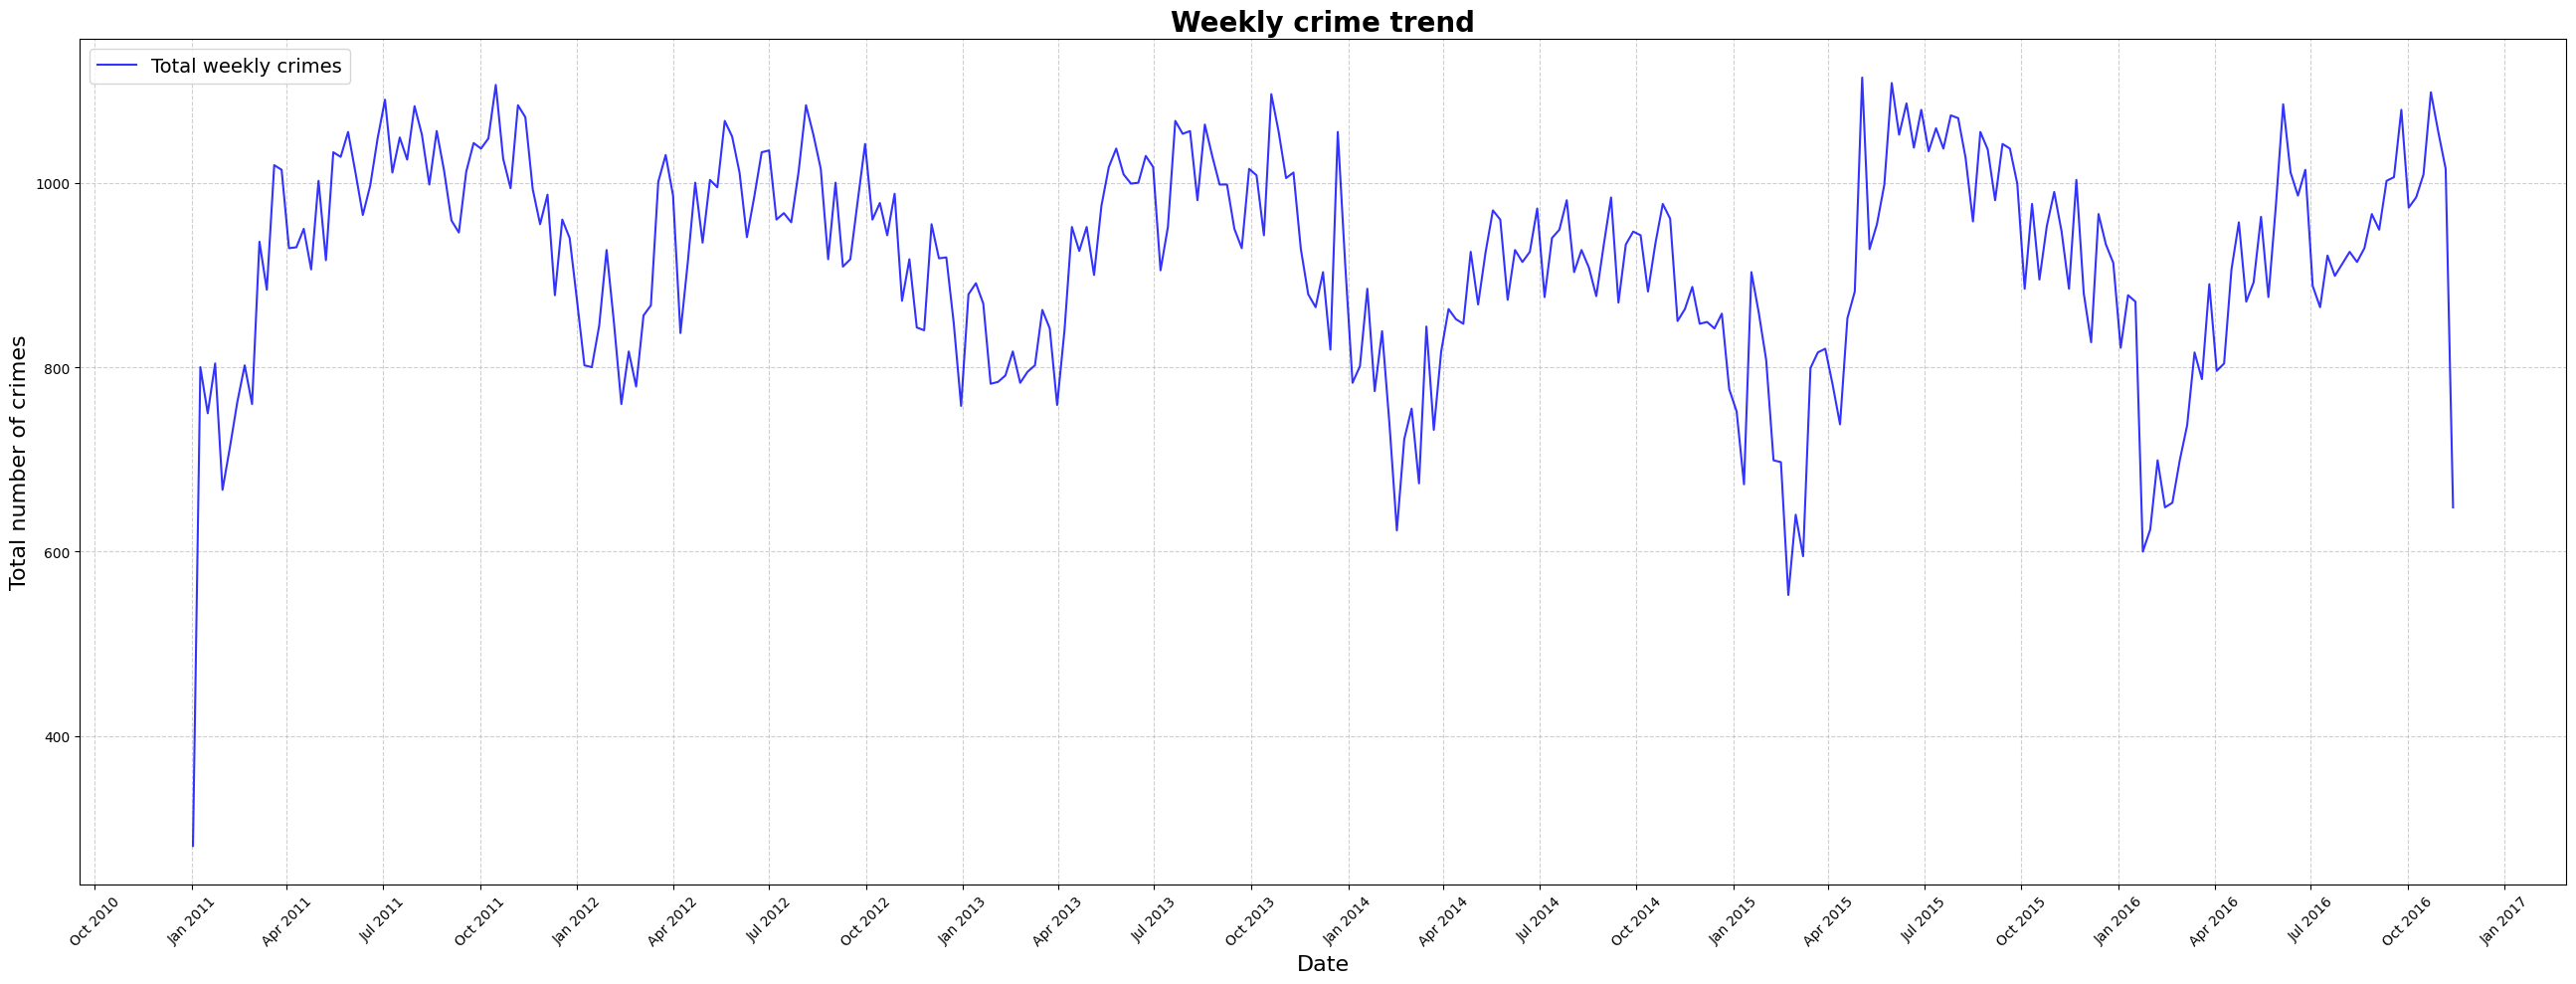

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(26, 10))
plt.plot(
    crime_time_series['DateTime'],
    crime_time_series['Total Incidents'],
    label='Total weekly crimes',
    alpha=0.8,
    linewidth=1.5,
    color='blue'
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.title('Weekly crime trend', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Total number of crimes', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Osservando il grafico dell'**andamento settimanale dei crimini**, si possono notare alcune caratteristiche che suggeriscono che la serie **non è stazionaria**:

1. **Media non costante nel tempo**
   - Ci sono periodi in cui il numero totale di incidenti settimanali è mediamente più alto (ad esempio tra il 2011 ed il 2013, di nuovo intorno al 2015-2016).
   - Altri periodi mostrano una diminuzione visibile (ad esempio inizio 2015 ed inizio 2016).
   - Questo indica che la media varia nel tempo.

2. **Varianza non costante nel tempo**
   - L'ampiezza delle fluttuazione ("dispersione" dei valori) non è omogenea: in certi intervalli la variabilità sembra più elevata, mentre in altri le oscillazioni sono più contenute.
   - Anche la varianza, quindi, sembra cambiare nel tempo.

3. **Possibile stagionalità**
   - Il grafico mostra ciclicità annuale o semestrale: periodi ricorrenti in cui i crimini aumentano o diminuiscono, compatibili con **pattern stagionali** (ad esempio aumenti estivi o cali invernali).
   - Questo tipo di oscillazione periodica è tipico di una serie **non stazionaria** con componente stagionale.

4. **Valori più contenuti in certi intervalli**
   - Si notano cali marcati in corrispondenza di alcuni anni (ad esempio inizio 2015 e 2016), forse legati a fattori specifici (politiche di sicurezza, eventi eccezionali, cambiamenti nei dati).

In sintesi, la serie sembra **non essere stazionaria**, poiché **media e varianza variano nel tempo** e sono presenti **elementi di stagionalità**. Per analisi predittive è necessario **stazionarla** tramite differenziazione o rimozione della stagionalità.
Per effettuare un'analisi più approfondita, si decomporrà la serie nelle sue componenti stagionali, di trend e residuali.


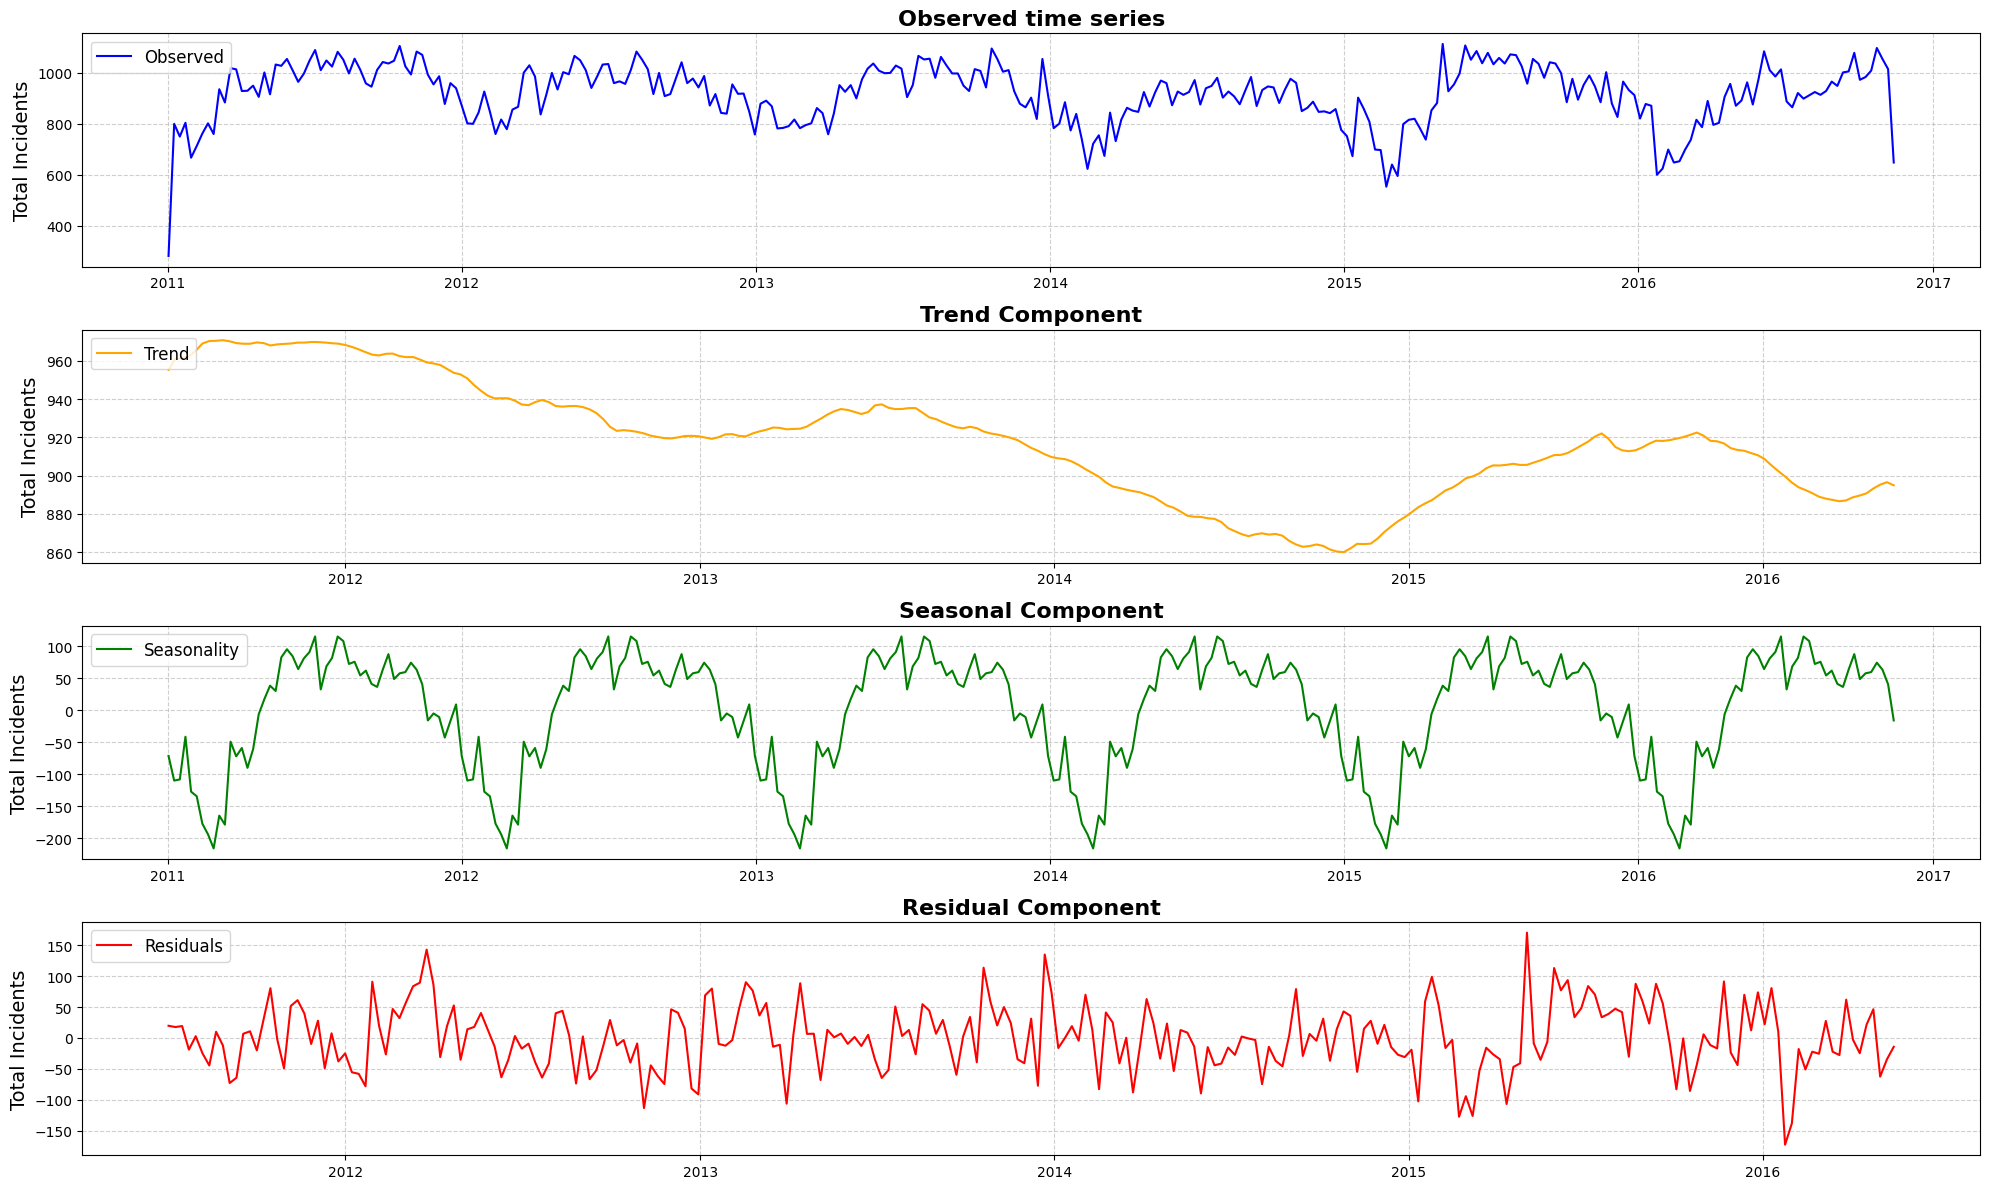

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposizione della serie temporale
decomposition = seasonal_decompose(
    crime_time_series.set_index('DateTime')['Total Incidents'], 
    model='additive', 
    period=52
)
plt.figure(figsize=(20, 12))

# Osservato
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed', color='blue', linewidth=1.5)
plt.title('Observed time series', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Trend
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange', linewidth=1.5)
plt.title('Trend Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Stagionalità
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green', linewidth=1.5)
plt.title('Seasonal Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Residui
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red', linewidth=1.5)
plt.title('Residual Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

1. **Componente di Trend**
   - Il trend mostra **una diminuzione graduale dal 2011 al 2014**, seguita da **una lieva risalita tra il 2015 e il 2016**.
   - Questo suggerisce che, nel lungo periodo, il **numero medio di crimini settimanali tende a calare leggermente**, ma con una ripresa negli ultimi anni del campione.
   - Quindi, **la media non è costante nel tempo**, confermando che la serie non è stazionaria in livello.

2. **Componente Stagionale**
   - Si osserva **una chiara periodicità annuale**, con oscillazioni regolari e simmetriche intorno allo zero.
   - La stagionalità è **molto marcata e stabile nel tempo**, indicando che i crimini tendono ad aumentare e diminuire in determinati periodi dell'anno (ad esempio più incidenti nei mesi estivi, meno in quelli invernali).
   - Questa regolarità suggerisce una **stagionalità fissa e ripetitiva**, il che è tipico di fenomeni sociali o ambienti influenzati da condizioni ricorrenti.

3. **Componente Residuale**
   - I residui oscillano intorno allo zero senza una struttura evidente, ma **non appaiono completamente bianchi**: in certi periodi (ad esempio 2015) sembrano più dispersi o con outlier.
   - Ciò indica che **parte della varianza non è spiegata** né dal trend né dalla stagionalità, ma non emergono pattern sistematici forti.
   - La varianza dei residui appare **piuttosto costante nel tempo**, un buon segno per modellazione successiva.

In sintesi, la serie **non è stazionaria in livello**, perché presenta **trend e stagionalità**. Dopo la rimozione del trend e della stagionalità o una differenziazione stagionale, i **residui potrebbero risultare stazionari** e quindi adatti a modelli successivi.

Per confermare l'ipotesi effettuiamo l'**ADF Test (Augmented Dickey-Fuller)** e misuriamo il **p-value**, che per serie stazionarie dovrebbe essere inferiore alla soglia di 0.05.

In [20]:
from statsmodels.tsa.stattools import adfuller

# Test di stazionarietà ADF
adf_test = adfuller(crime_time_series['Total Incidents'])

adf_results = pd.Series({"ADF Test Statistic": adf_test[0],
                         "p-value": adf_test[1],
                         "Used Lag": adf_test[2],
                         "Number of Observations": adf_test[3],
                         "Critical Value (1%)": adf_test[4]['1%'],
                         "Critical Value (5%)": adf_test[4]['5%'],
                         "Critical Value (10%)": adf_test[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF ===")
adf_results


=== Risultati del test di stazionarietà ADF ===


ADF Test Statistic         -4.303567
p-value                     0.000438
Used Lag                    9.000000
Number of Observations    297.000000
Critical Value (1%)        -3.452561
Critical Value (5%)        -2.871321
Critical Value (10%)       -2.571982
dtype: float64

In contrapposizione all'analisi effettuata, osservando i valori dell'ADF Test si può **rifiutare l'ipotesi nulla (H0)** con elevata confidenza (con un livello di confidenza superiore al 99%) e concludere che la serie è **stazionaria**. Tuttavia, ci sono alcune considerazioni da tenere in mente:
- **Statisticamente**, l'ADF dice che la serie può essere trattata come stazionaria.
- **Visivamente**, però, rimangono segnali di **trend e stagionalità**, quindi per l'utilizzo di modelli come ARIMA/SARIMA è comunque consigliabile una **differenziazione (o rimozione della stagionalità)** per sicurezza.

Quindi, si procederà con due approcci di differenziazione:
- **Semplice**: per rimuovere il trend, con l'effetto di trasformare la serie che oscilla attorno ad una media costante, di fatto "appiattendo" il trend.
- **Stagionale**: per rimuovere pattern annuali o periodici, eliminando la dipendenza ciclica annuale; confrontando ogni settimana con la stessa settimana dell'anno prima, si annulla l'effetto sistematico legato a quel particolare periodo dell'anno.

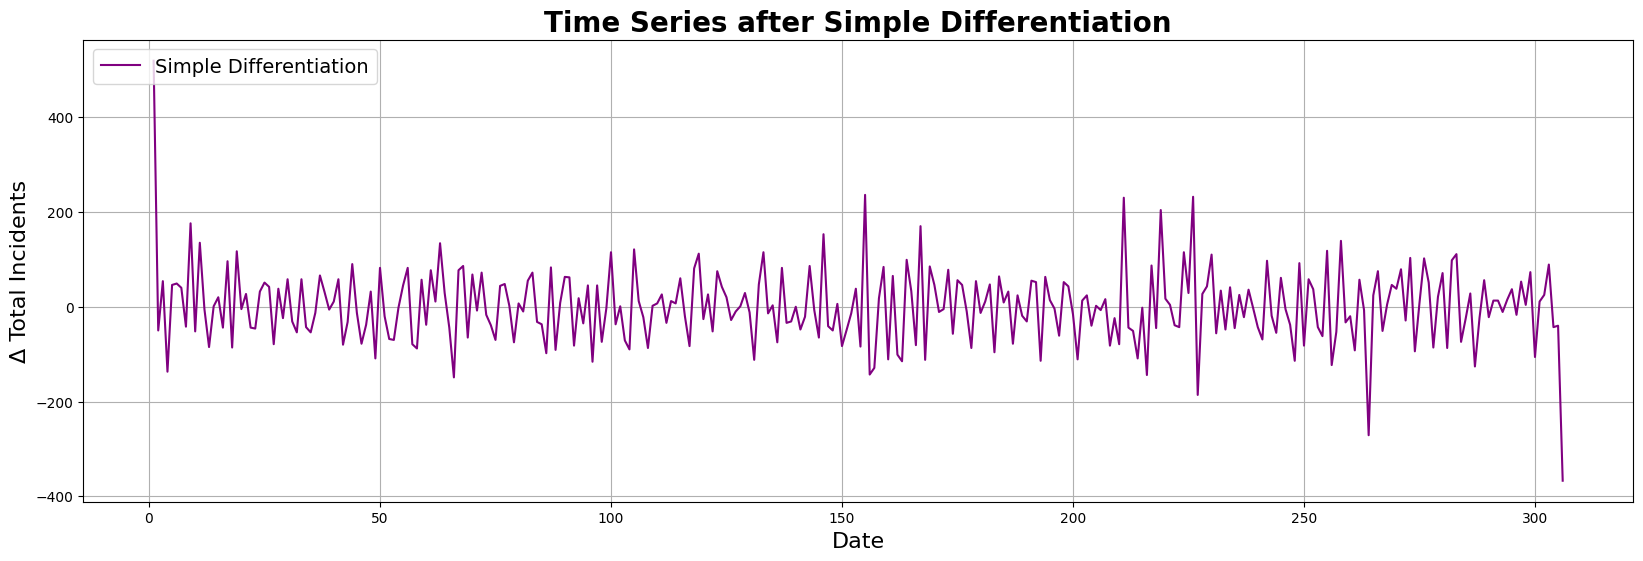

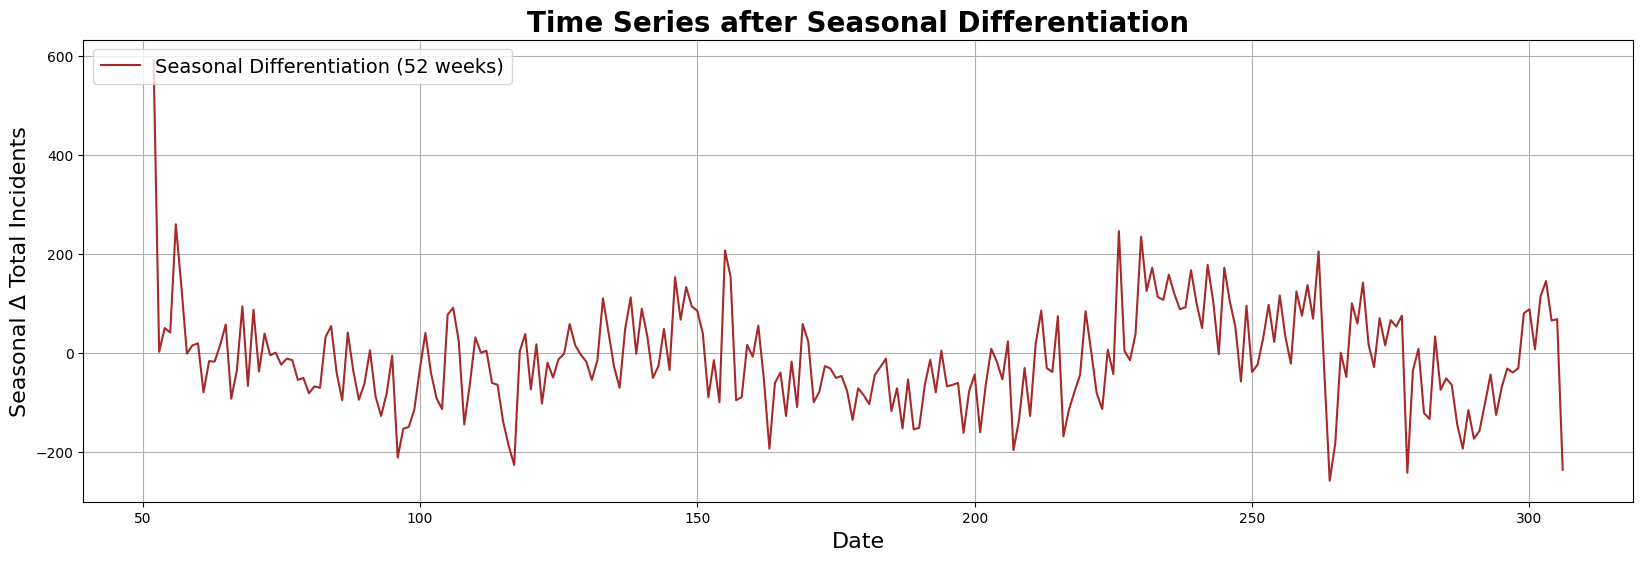


=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===
ADF Test Statistic       -7.476872e+00
p-value                   4.887433e-11
Used Lag                  5.000000e+00
Number of Observations    3.000000e+02
Critical Value (1%)      -3.452337e+00
Critical Value (5%)      -2.871223e+00
Critical Value (10%)     -2.571929e+00
dtype: float64

=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===
ADF Test Statistic         -4.166292
p-value                     0.000751
Used Lag                    5.000000
Number of Observations    249.000000
Critical Value (1%)        -3.456888
Critical Value (5%)        -2.873219
Critical Value (10%)       -2.572994
dtype: float64


In [21]:
from statsmodels.tsa.stattools import adfuller

# Differenziazione semplice
crime_diff = crime_time_series['Total Incidents'].diff().dropna()

# Differenziazione stagionale (period=52 settimane)
crime_seasonal_diff = crime_time_series['Total Incidents'].diff(52).dropna()

# Grafico della differenziazione semplice
plt.figure(figsize=(20, 6))
plt.plot(crime_diff, label='Simple Differentiation', color='purple', linewidth=1.5)
plt.title('Time Series after Simple Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Grafico della differenziazione stagionale
plt.figure(figsize=(20, 6))
plt.plot(crime_seasonal_diff, label='Seasonal Differentiation (52 weeks)', color='brown', linewidth=1.5)
plt.title('Time Series after Seasonal Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Seasonal Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Test di stazionarietà ADF sulla serie differenziata
adf_test_diff = adfuller(crime_diff)
adf_test_seasonal_diff = adfuller(crime_seasonal_diff)
adf_results_diff = pd.Series({"ADF Test Statistic": adf_test_diff[0],
                         "p-value": adf_test_diff[1],
                         "Used Lag": adf_test_diff[2],
                         "Number of Observations": adf_test_diff[3],
                         "Critical Value (1%)": adf_test_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_diff[4]['10%']})

adf_results_seasonal_diff = pd.Series({"ADF Test Statistic": adf_test_seasonal_diff[0],
                         "p-value": adf_test_seasonal_diff[1],
                         "Used Lag": adf_test_seasonal_diff[2],
                         "Number of Observations": adf_test_seasonal_diff[3],
                         "Critical Value (1%)": adf_test_seasonal_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_seasonal_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_seasonal_diff[4]['10%']})
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===")
print(adf_results_diff)
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===")
print(adf_results_seasonal_diff)

1. **Differenziazione semplice**
   - La statistica ADF (-7.48) è **molto più piccola** del valore critico al 1% (-3.45).
   - Il p-value è **praticamente zero**.
   - Conclusione: la serie differenziata semplice è **fortemente stazionaria**, il trend è stato completamente rimosso e ora la media e la varianza sono costanti nel tempo.

2. **Differenziazione stagionale (lag = 52 settimane)**
   - Anche qui la statistica ADF è **inferiore** al valore critico al 1% (-3.46).
   - Il p-value è ancora **molto basso** (<0.01).
   - Conclusione: la serie differenziata stagionale è anch'essa **stazionaria**, ma l'effetto è **meno marcato** rispetto alla differenziazione semplice.

In sintesi, la **differenziazione semplice** ha reso la serie fortemente stazionaria eliminando il trend principale, mentre la **differenziazione stagionale** ha rimosso le oscillazioni annuali, ma non riduce tanto la dipendenza come la prima. Entrambe le serie, quindi, risultano **statisticamente stazionarie**, ma per motivi diversi.

Per modelli come **SARIMA**, dove è utile catturare sia trend che stagionalità, la soluzione migliore è **applicare entrambe le differenziazioni**, verificando di nuovo la stazionarietà e la stabilità visiva, dato che, in genere, la doppia differenziazione fornisce una serie finale stazionaria in media e varianza, pronta per il fitting di un modello ARIMA/SARIMA.

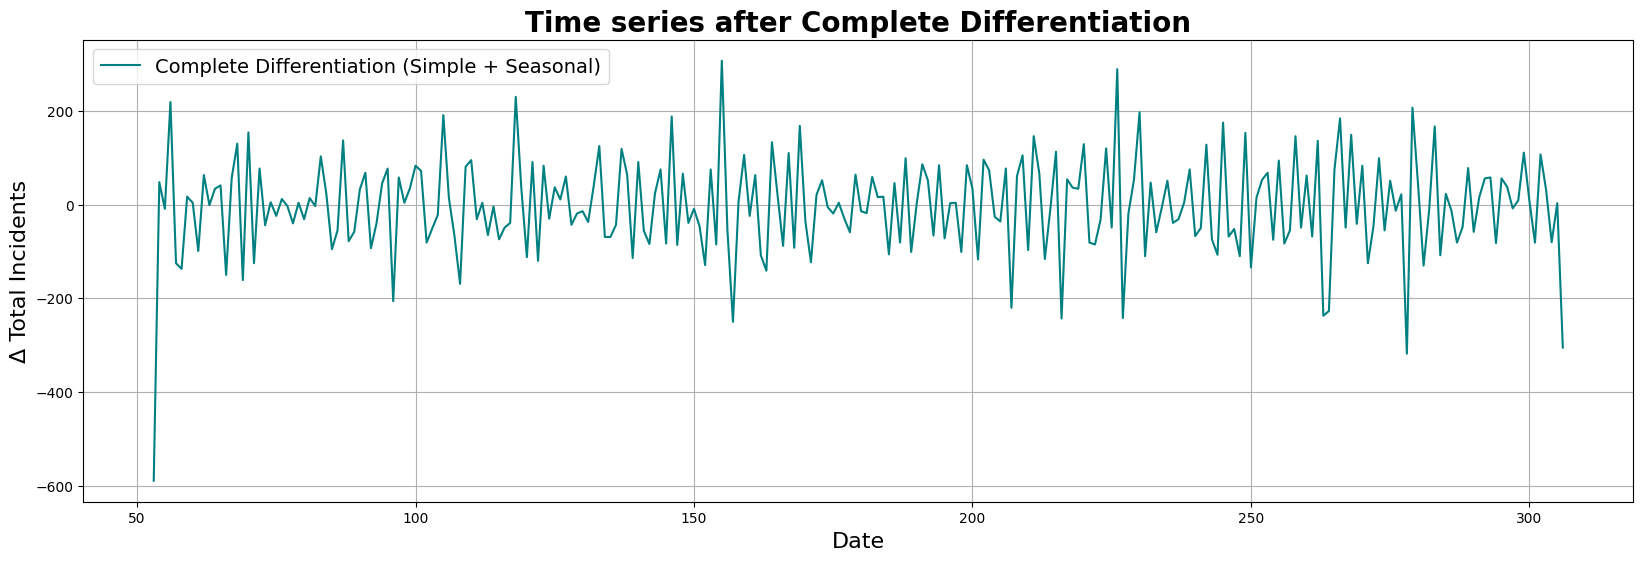

In [22]:
# Differenziazione completa (semplice + stagionale)
crime_diff_full = crime_time_series['Total Incidents'].diff().diff(52).dropna()

# Grafico della differenziazione completa
plt.figure(figsize=(20, 6))
plt.plot(crime_diff_full, label='Complete Differentiation (Simple + Seasonal)', color='teal', linewidth=1.5)
plt.title('Time series after Complete Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

Nel grafico possiamo osservare che la serie differenziata completa (semplice + stagionale) oscilla chiaramente **intorno allo zero**, senza trend a lungo termine evidente. Inoltre, la varianza è **piuttosto costante**, con un'ampiezza delle oscillazioni relativamente consistenti lungo tutto l'asso temporale. Infine, non si osservano più pattern stagionali regolari.

In [23]:
# Test di stazionarietà ADF sulla serie completamente differenziata
adf_test_diff_full = adfuller(crime_diff_full)

# Risultati del test ADF
adf_results_diff_full = pd.Series({"ADF Test Statistic": adf_test_diff_full[0],
                         "p-value": adf_test_diff_full[1],
                         "Used Lag": adf_test_diff_full[2],
                         "Number of Observations": adf_test_diff_full[3],
                         "Critical Value (1%)": adf_test_diff_full[4]['1%'],
                         "Critical Value (5%)": adf_test_diff_full[4]['5%'],
                         "Critical Value (10%)": adf_test_diff_full[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===")
print(adf_results_diff_full)


=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===
ADF Test Statistic       -1.157592e+01
p-value                   3.022940e-21
Used Lag                  4.000000e+00
Number of Observations    2.490000e+02
Critical Value (1%)      -3.456888e+00
Critical Value (5%)      -2.873219e+00
Critical Value (10%)     -2.572994e+00
dtype: float64


Osservando i risultati del test di stazionarietà ADF applicato alla serie differenzata completa, si può concludere che la serie è **pienamente stazionaria**. Si può quindi procedere con l'analisi dei **correlogrammi ACF e PACF** per stimare i parametri (p, d, q) del modello SARIMA.

### **Analisi dei correlogrammi**

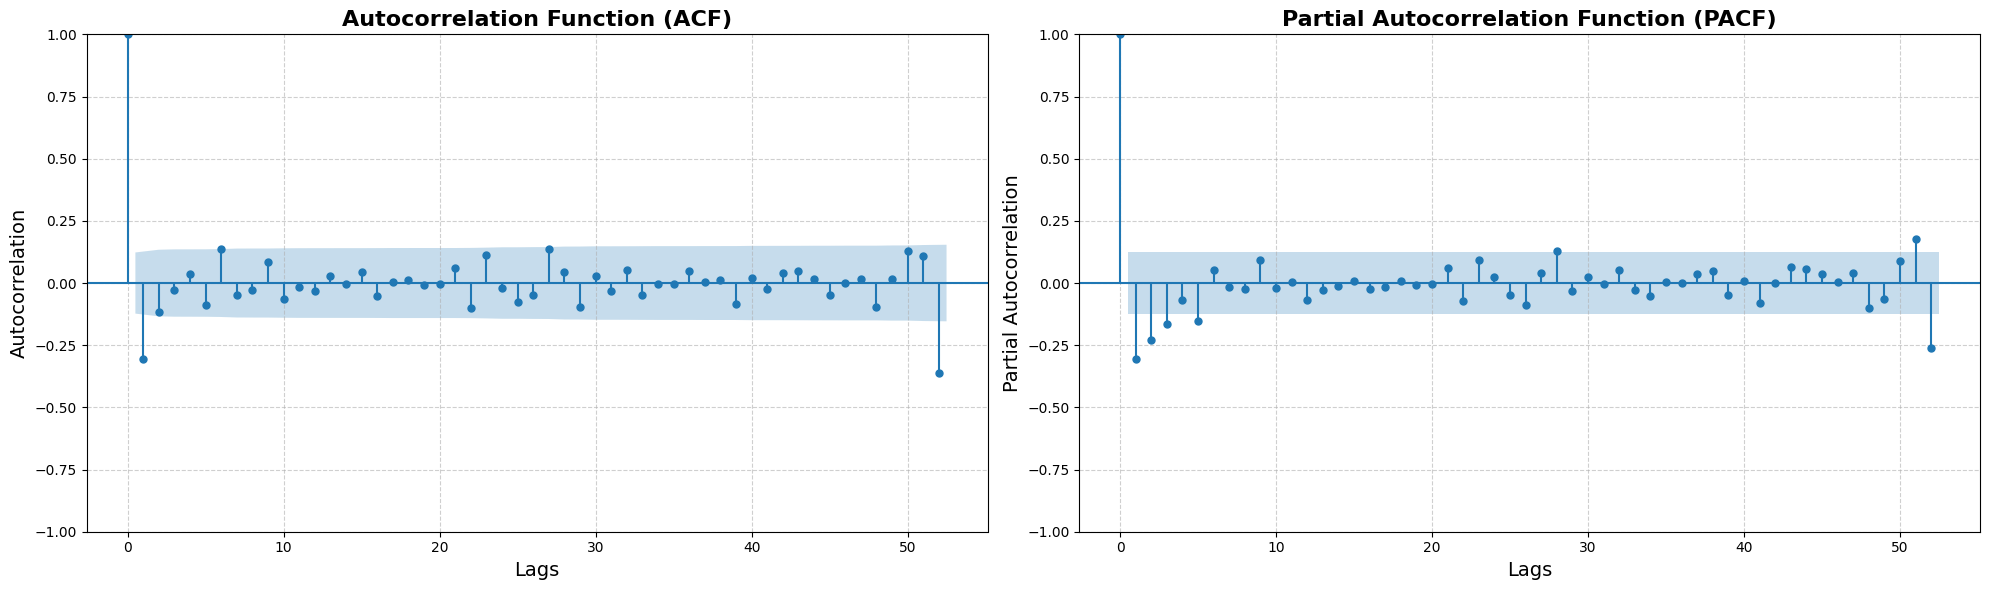

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Creazione dei grafici ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi = 100)

# Grafico ACF
plot_acf(crime_diff_full, lags=52, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=14)
axes[0].set_ylabel('Autocorrelation', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafico PACF
plot_pacf(crime_diff_full, lags=52, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=14)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### **Analisi delle Componenti non stagionali (p,q)**
Per identificare i parametri **p (ordine AR) e q (ordine MA)**, si osservano i primi lag dei grafici.
- **Grafico ACF**: c'è un picco negativo statisticamente significativo al **lag 1**. Subito dopo, i valori successivi cadono rapidamente all'interno della banda di confidenza (area azzurra). Questo pattern con un taglio netto e improvviso dopo il primo lag, è caratteristico di un **modello a Media Mobile (MA)**. L'ordine del modello è dato dall'ultimo lag significativo prima del taglio, suggerendo quindi un parametro `q = 1`.
- **Grafico PACF**: anche qui c'è un picco negativo significativo al **lag 1**, e i valori successivi tendono a cadere rapidamente all'interno della banda di confidenza. Un taglio netto nel PACF è tipico di un **modello Autoregressivo (AR)**, suggerendo un parametro `p = 1`.

Avendo indicazioni sia per un modello AR(1) sia per un MA(1) e analizzando entrambi i grafici, si osserva che il grafico ACF è molto netto e pulito, rendendo l'ipotesi di un **modello MA(1) (`q = 1`, `p = 0`)** leggermente più probabile e un ottimo punto di partenza.

#### **Analisi delle Componenti stagionali (P,Q)**
Per determinare i parametri stagionali `P` e `Q`, osserviamo i lag specificamente vicini al 52.
- **Grafico ACF**: si nota un **picco negativo statisticamente significativo al lag 52**. Questo picco è isolato, il che è un segnale molto forte per un modello di **Media Mobile Stagionale (SMA)**. Questo conferma la precedente ipotesi, suggerendo un valore di `Q = 1`.
- **Grafico PACF**: analogamente, si osserva un **picco negativo significativo al lag 52**. Anche questo picco sembra essere isolato, suggerendo un modello **Autoregressivo Stagionale (SAR)** e un valore di `P = 1`.



In [12]:
import pmdarima as pm

# Eseguiamo auto_arima specificando il periodo stagionale 'm'
# e forzando la differenziazione che sappiamo essere necessaria.
sarima_model = pm.auto_arima(
    crime_time_series['Total Incidents'],  # La serie temporale
    seasonal=True,                         # Abilita la ricerca di un modello stagionale
    m=52,                                  # Il periodo a 52 settimane
    
    # Parametri per guidare la ricerca
    d=1,                                   # Forza una differenziazione semplice (per il trend)
    D=1,                                   # Forza una differenziazione stagionale
    start_p=0, start_q=0,                  # Punto di partenza per i parametri non stagionali
    start_P=0, start_Q=0,                  # Punto di partenza per i parametri stagionali
    max_p=2, max_q=2,                      # Limite massimo per p e q
    max_P=2, max_Q=2,                      # Limite massimo per P e Q

    # Parametri per il controllo del processo
    trace=True,                            # Mostra i modelli che sta testando
    error_action='ignore',                 # Ignora i modelli che non convergono
    suppress_warnings=True,                # Sopprime i warning
    stepwise=True                          # Usa un approccio efficiente per la ricerca
)

# Stampa il sommario del modello migliore trovato
print(sarima_model.summary())

Performing stepwise search to minimize aic


KeyboardInterrupt: 

Il modello migliore trovato con auto_arima è quello con parametri `p=1, d=1, q=1, P=2, D=1, Q=0`.

**Componente non stagionale**:
- `d = 1`: conferma che è stata necessaria una **differenziazione semplice** per rimuovere il trend.
- `p = 1`: il numero di incidenti di una settimana è influenzato dal numero di incidenti della **settimana precedente**.
- `q = 1`: il modello viene corretto anche in base all'**errore di previsione** commesso nella settimana precedente.

**Componente stagionale**:
- `D = 1`: conferma che sia stata necessaria una **differenziazione stagionale** per rimuovere il ciclo annuale.
- `P = 2`: il numero di incidenti di una settimana è influenzato non solo dal valore della **stessa settimana dell'anno precedente** (lag 52), ma anche da quello della **stessa settimana di due anni prima** (lag 104). Questo indica un pattern stagionale molto forte e persistente nel tempo.
- `Q = 0`: il modello non ha trovato necessario includere un termine di media mobile stagionale.

**Diagnostica dei residui**:
- Ljung-Box (`Prob(Q) = 0.25`): il p-value è maggiore di 0.05, indicando che i residui **non sono autocorrelati**. Il modello ha catturato con successo tutta la struttura temporale presente nei dati, lasciando solo "rumore bianco".
- Heteroskedasticity (`Prob(H): 0.76`): il p-value è maggiore di 0.05, confermando che la varianza degli errori è **costante** nel tempo (omoschedasticità). Il modello è stabile e non ha periodi in cui commette errori sistematicamente più grandi o più piccoli.
- Jarque-Bera (`Prob(JB): 0.00`): il p-value è minore di 0.05, mostrando che i residui **non seguono una distribuzione normale**. La `Kurtosis` alta (`7.14`) suggerisce che la distribuzione degli errori ha "code più pesanti", ovvero ci sono più valori estremi (outlier) di quanto ci si aspetterebbe. Sebbene non sia ideale, questo è molto comune nelle serie storiche reali e, per scopi di previsione, è meno grave della presenza di autocorrelazione.

Si può procedere con la diagnostica e l'analisi dei residui prodotti da tale modello, per assicurarci che non ci siano pattern particolari, cercando media e varianza costante.

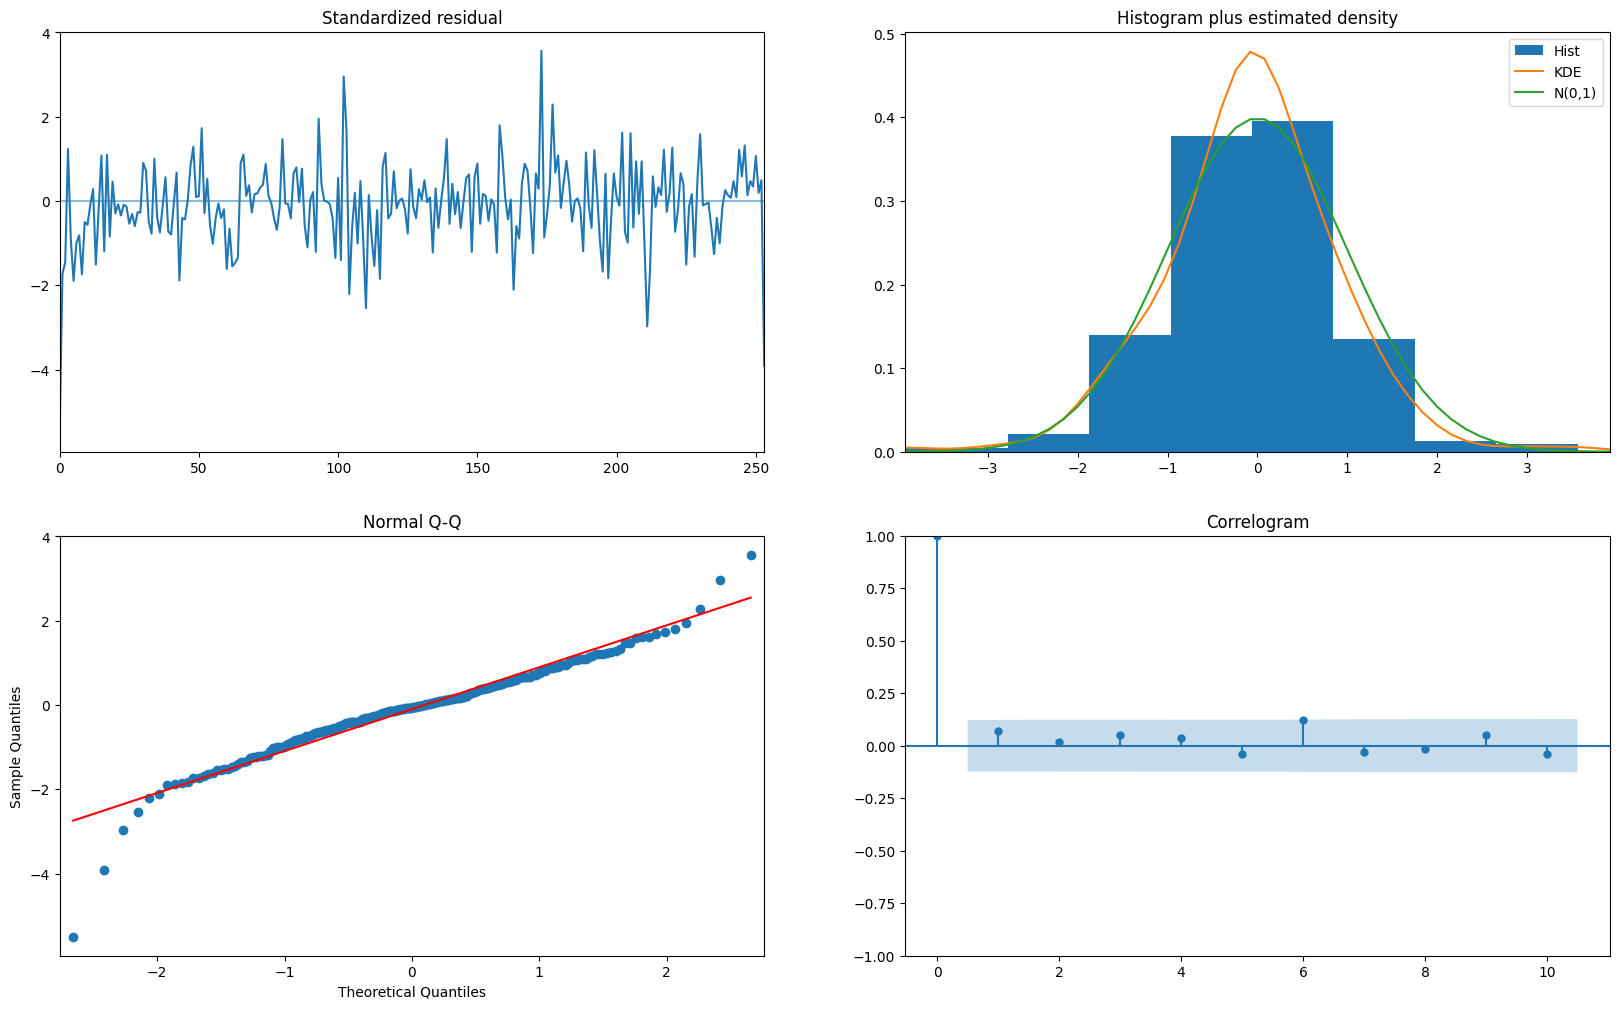

In [21]:
# Diagnostica del modello SARIMA
sarima_model.plot_diagnostics(figsize=(20, 12));


### **Diagnostica dei residui**
1. **Standardized Residuals**
Questo grafico mostra gli errori del modello nel tempo, standardizzati in modo da avere una deviazione standard di 1.
   - I residui fluttuano in modo casuale attorno alla linea dello zero. Non c'è alcun trend, ciclo o pattern evidente. La varianza appare costante.
   - Concludendo, questo è l'aspetto ideale del "rumore bianco", quindi il modello **ha estratto con successo tutta l'informazione prevedibile** dalla serie storica, lasciando solo un errore casuale ed imprevedibile.

2. **Histogram plus estimated density**
Questo grafico confronta la distribuzione dei residui (istogramma blu e curva KDE arancione) con una distribuzione normale perfetta (curva verde N(0,1)).
   - La curva arancione (KDE) è centrata sullo zero e ha una forma a campana, ma è leggermente più "appuntita" e alta rispetto alla curva normale verde.
   - Visivamente viene confermato il risultato del test di Jarque-Bera. I residui **non sono perfettamente normali**, ma sono molto vicini. La forma più appuntita (leptocurtica) è comune nei dati reali e non invalida il modello per scopi di previsione.

3. **Normal Q-Q Plot**
Questo grafico confronta i quantili dei residui (punti blu) con i quantili di una distribuzione normale teorica (linea rossa).
   - La stragrande maggioranza dei punti si allinea quasi perfettamente lungo la linea rossa. Si notano solo leggere deviazioni alle estremità, che corrispondono agli outlier.
   - Questo è un risultato eccellente e rafforza la conclusione precedente. Nonostante la non-normalità statistica, la distribuzione **si avvicina molto a una distribuzione normale** per la maggior parte dei valori.

4. **Correlogram (ACF dei Residui)**
Questo grafico mostra se gli errori del modello sono correlati tra loro a diversi lag.
   - **Nessuna** delle barre di autocorrelazione (ad eccezione del lag 0, che è sempre 1) s**upera in modo significativo l'area di confidenza blu**.
   - Questo conferma visivamente il test di Ljung-Box (`Prob(Q) > 0.05`): quindi **non c'è alcuna autocorrelazione residua significativa**. Il modello ha catturato tutta la dipendenza temporale (sia a breve termine sia stagionale) presente nei dati.

## **Addestramento del modello**

Addestriamo il modello dividendo il dataset in 80% training e 20% testing, così da poter simulare un addestramento sugli anni di misurazione (7) e valutare i risultati su un intero anno.

Mean Absolute Error (MAE): 76.28
Root Mean Squared Error (RMSE): 97.63


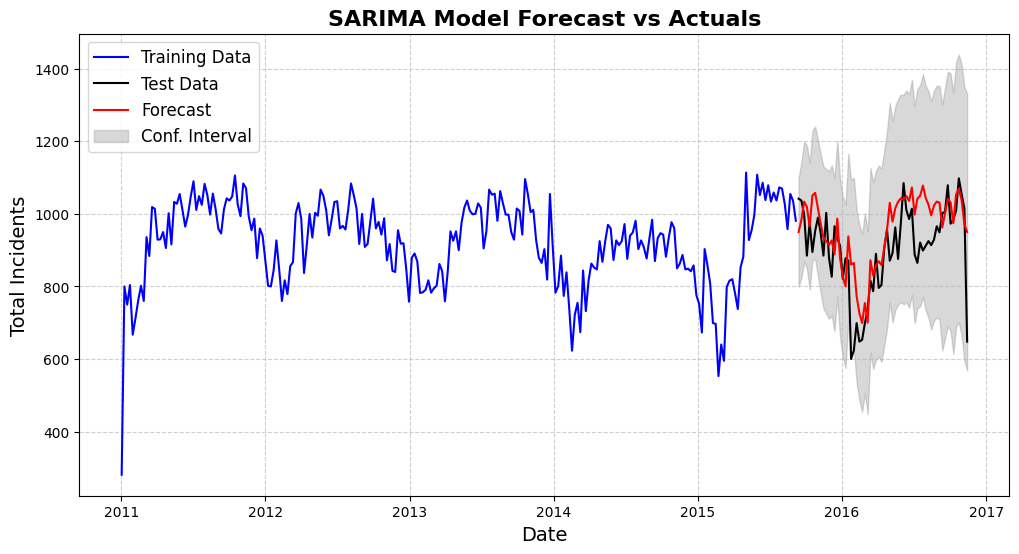

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Divisione in training e test set (80% training, 20% test)
train_size = int(len(crime_time_series) * 0.8)
train, test = crime_time_series[:train_size], crime_time_series[train_size:]

# Addestramento del modello SARIMA con i parametri trovati
model = SARIMAX(train['Total Incidents'], 
                order=(1, 1, 1), 
                seasonal_order=(2, 1, 0, 52),
                trend='n')
model_fit = model.fit(disp=False)

# Previsioni sul test set
forecast_object = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Calcolo degli errori
mse = mean_squared_error(test['Total Incidents'], forecast_mean)
mae = mean_absolute_error(test['Total Incidents'], forecast_mean)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Plot dei risultati con intervalli di confidenza
plt.figure(figsize=(12, 6))
plt.plot(train['DateTime'], train['Total Incidents'], label='Training Data', color='blue')
plt.plot(test['DateTime'], test['Total Incidents'], label='Test Data', color='black')
plt.plot(test['DateTime'], forecast_mean, label='Forecast', color='red')
plt.fill_between(test['DateTime'], 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], label = 'Conf. Interval', color='grey', alpha=0.3)
plt.title('SARIMA Model Forecast vs Actuals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Analisi del Grafico**
- **Previsione (Linea rossa)**: la linea **cattura in modo eccellente la stagionalità** dei dati. Non è una linea piatta, ma segue correttamente i picchi e le valli del ciclo annuale. Ad esempio, riproduce bene il calo all'inizio del 2016 e la successiva risalita. Questo è il segnale più importante che il modello ha "capito" la struttura dei dati.
- **Dati Reali (Linea nera)**: la linea dei dati di test rimane **quasi sempre all'interno dell'intervallo di confidenza**. Questo è esattamente ciò che si desidera: significa che il modello non solo fa una previsione puntuale, ma quantifica anche correttamente la propria incertezza.
- **Intervallo di confidenza (Area grigia)**: l'intervallo di confidenza si **allarga leggermente man mano che la previsione si estende nel futuro**. Questo comportamento è corretto e desiderabile, poiché riflette il fatto che l'incertezza aumenta naturalmente su orizzonti temporali più lunghi.

**Analisi delle Metriche di Errore**
Le metriche confermano l'impressione visiva del grafico.
- **MAE (Mean Absolute Error): 76.28**. Significa che, in media, la previsione del modello si discosta dal valore reale di circa **76 incidenti a settimana**. Considerando che il numero di incidenti oscilla tra 800 e 1100 nel periodo di test, un errore medio di 76 è assolutamente ragionevole e indica una buona accuratezza.
- **RMSE (Root Mean Squared Error): 97.63**. L'RMSE è leggermente superiore al MAE. Questo è normale, poiché l'RMSE penalizza di più gli errori grandi. Il fatto che i due valori siano relativamente vicini suggerisce che il modello non commette errori occasionali enormi, ma ha una performance consistente.

### **Miglioramento del Modello SARIMAX**
L'ultimo passaggio è quello di introdurre delle **variabili esogene** nel modello SARIMAX, per migliorare la precisione e la robustezza del modello.
L'idea è di fornire non solo l'andamento passato della serie storica (colonna `Total Incidents`), ma anche altre informazioni contestuali che possono aiutarlo a spiegare le fluttuazioni e, di conseguenza, a fare previsioni più accurate.

#### **Scelta delle variabili esogene**
- **Variabili derivate dal dataset**: 
  - `firearm_rate`: percentuale di crimini con arma da fuoco ogni settimana.
  **Ragione**: i crimini con arma da fuoco possono avere un andamento stagionale o reagire ad eventi particolari, come festività o tensioni sociali.
  - `inside_rate`: percentuale di crimini all'interno di edifici ogni settimana.
  **Ragione**: differenziare crimini indoor da outdoor può catturare pattern diversi: crimini indoor tendono ad avere correlazioni con stagionalità o condizioni climatiche, mentre quelli outdoor possono essere influenzati da fattori esterni come meteo o eventi pubblici.
  - `district_*`: distretti con maggior numero di incidenti ogni settimana.
  **Ragione**: alcune zone hanno tassi di criminalità più elevati; codificare i distretti come variabili dummy permette al modello di catturare effetti locali sulla serie temporale settimanale.

- **Variabili ingegnerizzate dalla serie storica**
  - `lag1`: numero di crimini nella settimana precedente.
  **Ragione**: i crimini spesso mostrano autocorrelazione settimanale; includere il lag aiuta il modello a prevedere l'andamento della settimana successiva basandosi sulla continuità dei dati.
  - `rolling_mean_4w`: media mobile di 4 settimane.
  **Ragione**: cattura trend a breve periodo e attenua le fluttuazioni settimanali eccessive.
  - `rolling_std_4w`: deviazione standard di 4 settimane.
  **Ragione**: misura la volatilità dei crimini; settimane con alta variabilità possono indicare eventi anomali.
  - `month`: mesi dell'anno.
  **Ragione**: cattura la stagionalità annuale dei crimini (alcuni mesi possono avere più crimini per motivi climatici, festività o eventi locali).
  - `is_summer`: indicatore se la settimana appartiene ai mesi estivi (giugno-agosto).
  **Ragione**: durante l’estate possono cambiare i pattern di criminalità (più attività all’aperto, più eventi pubblici, vacanze scolastiche), quindi questa variabile aiuta a modellare effetti stagionali specifici.

In [ ]:
# Copia della serie temporale originale
df = crime_time_series.copy()

# Creazione delle variabili esogene settimanali
crime_weekly = (
    crime_data
    .set_index('DateTime')
    .resample('W')
    .agg({
        'Total Incidents': 'sum',
        'Weapon': lambda x: (x == 'Firearm').mean(),  # Percentuale di crimini con arma da fuoco
        'Inside/Outside': lambda x: (x == 'Inside').mean(), # Percentuale di crimini all'interno
        'District': lambda x: x.mode()[0] if len(x.mode()) else 'Unknown' # Distretto più frequente
    })
    .reset_index()
    .rename(columns={
        'Weapon': 'firearm_rate',
        'Inside/Outside': 'inside_rate',
        'District': 'top_district'
    })
)

# One-hot encoding per la colonna 'top_district'
district_dummies = pd.get_dummies(crime_weekly['top_district'], prefix='district', drop_first=True)
crime_weekly = pd.concat([crime_weekly, district_dummies], axis=1)
crime_weekly = crime_weekly.drop(columns=['top_district'])

# Creazione di ulteriori variabili esogene ingegnerizzate
crime_weekly['lag1'] = crime_weekly['Total Incidents'].shift(1)
crime_weekly['rolling_mean_4w'] = crime_weekly['Total Incidents'].rolling(4).mean()
crime_weekly['rolling_std_4w'] = crime_weekly['Total Incidents'].rolling(4).std()
crime_weekly['month'] = crime_weekly['DateTime'].dt.month
crime_weekly['is_summer'] = crime_weekly['month'].isin([6, 7, 8]).astype(int)

# Backfill dei valori mancanti per l'allineamento della serie temporale
cols_with_nans = ['lag1', 'rolling_mean_4w', 'rolling_std_4w']
for col in cols_with_nans:
    crime_weekly[col] = crime_weekly[col].bfill()

# Rimozione delle righe con valori NaN generati dalle operazioni di shift e rolling
crime_weekly = crime_weekly.reset_index(drop=True)

# Unione delle variabili esogene con la serie temporale originale
df_exog = crime_weekly.drop(columns=['Total Incidents'])
df_final = df_exog.merge(df[['DateTime', 'Total Incidents']], on='DateTime', how='inner')

# Impostazione di 'DateTime' come indice
df_final = df_final.set_index('DateTime')

print("\n=== Dataset con variabili esogene ===")
print(df_final.head(5))
print("\n=== Colonne disponibili per SARIMAX ===")
print(list(df_final.columns))

# y = target, X = variabili esogene
y = df_final['Total Incidents']
X = df_final.drop(columns=['Total Incidents']).astype(float)


=== Dataset con variabili esogene ===
            firearm_rate  inside_rate  district_NORTHEASTERN  \
DateTime                                                       
2011-01-02           0.0          0.0                  False   
2011-01-09           0.0          0.0                   True   
2011-01-16           0.0          0.0                   True   
2011-01-23           0.0          0.0                   True   
2011-01-30           0.0          0.0                   True   

            district_NORTHERN  district_SOUTHEASTERN  district_SOUTHERN  \
DateTime                                                                  
2011-01-02              False                  False              False   
2011-01-09              False                  False              False   
2011-01-16              False                  False              False   
2011-01-23              False                  False              False   
2011-01-30              False                  False          

C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\matte\AppDat


Mean Absolute Error (MAE): 51.56
Root Mean Squared Error (RMSE): 67.30


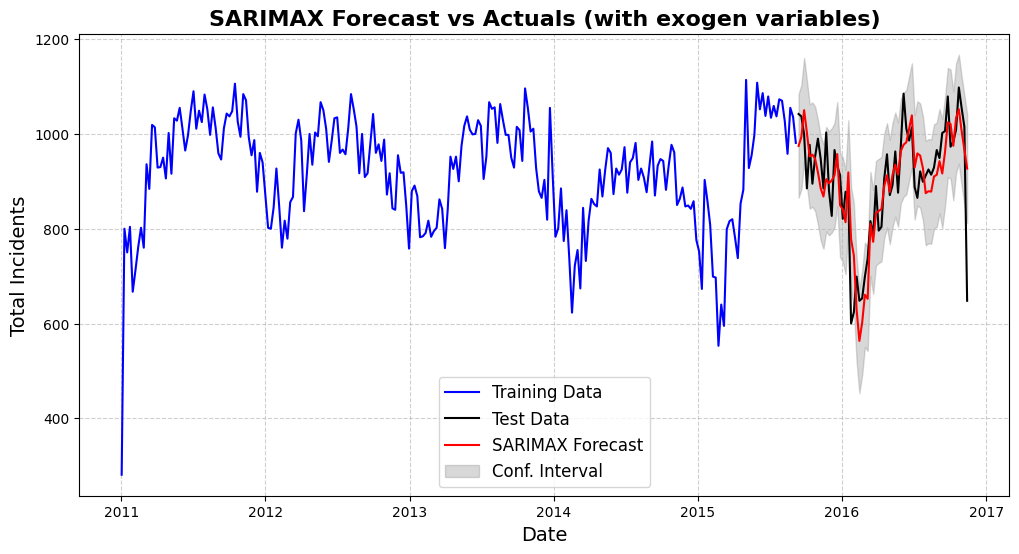

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Divisione in training e test set (80% training, 20% test)
train_size = int(len(df_final) * 0.8)
train_y, test_y = y.iloc[:train_size], y.iloc[train_size:]
train_X, test_X = X.iloc[:train_size], X.iloc[train_size:]

# Addestramento del modello SARIMAX con variabili esogene
model_exog = SARIMAX(
    train_y,
    exog=train_X,
    order=(1, 1, 1),
    seasonal_order=(2, 1, 0, 52),
    trend='n'
)

model_exog_fit = model_exog.fit(disp=False)

# Previsioni sul test set
forecast_object = model_exog_fit.get_forecast(steps=len(test_y), exog=test_X)
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Calcolo degli errori
mse = mean_squared_error(test_y, forecast_mean)
mae = mean_absolute_error(test_y, forecast_mean)
rmse = np.sqrt(mse)

print(f'\nMean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Plot dei risultati con intervalli di confidenza
plt.figure(figsize=(12, 6))
plt.plot(train_y.index, train_y, label='Training Data', color='blue')
plt.plot(test_y.index, test_y, label='Test Data', color='black')
plt.plot(test_y.index, forecast_mean, label='SARIMAX Forecast', color='red')
plt.fill_between(test_y.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 label='Conf. Interval',
                 color='grey', alpha=0.3)
plt.title('SARIMAX Forecast vs Actuals (with exogen variables)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#### **Analisi del modello SARIMAX con variabili esogene**

Le metriche di errore dimostrano un **miglioramento netto e significativo** rispetto al modello SARIMAX originale.

| Metrica | Modello SARIMAX (Precedente) | Modello SARIMAX (Nuovo) | Miglioramento |
| :--- | :---: | :---: | :---: |
| **MAE** | 76.28 | **51.56** | **-32.4%** |
| **RMSE**| 97.62 | **67.30** | **-31.1%** |

- **Mean Absolute Error (MAE): 51.56**. Questo risultato è molto buono. Significa che, in media, le previsioni del nuovo modello si discostano dal valore reale di soli **51 incidenti**, contro i 76 del modello precedente.  L'errore medio è stato ridotto di oltre il **32%**.
- **Root Mean Squared Error (RMSE): 67.30**. Anche l'RMSE, che penalizza maggiormente gli errori più grandi, mostra una riduzione drastica di oltre il **31%**. Questo indica che il modello non solo è mediamente più accurato, ma compie anche meno errori di grande entità.
Questi numeri confermano che l'aggiunta di variabili esogene contestuali ha aumentato drasticamente il potere predittivo del modello.

Il confronto visivo tra i dati reali e le previsioni del modello SARIMAX rafforza ulteriormente le conclusioni tratte dalle metriche.

Dal grafico si evince che:
1. **Aderenza ai Dati Reali**: La linea rossa della previsione (`SARIMAX Forecast`) non si limita più a seguire il trend stagionale generale. Ora è in grado di **catturare i picchi e le valli settimanali** con notevole precisione, seguendo da vicino la linea nera dei dati di test.
2. **Spiegazione della Varianza**: Il modello sta chiaramente utilizzando le informazioni fornite dalle variabili esogene (come la media mobile e la stagionalità estiva) per **spiegare le fluttuazioni a breve termine**, un compito che il modello SARIMA originale non poteva assolvere.
3. **Affidabilità della Previsione**: L'intervallo di confidenza (area grigia) rimane ragionevolmente stretto, indicando una buona sicurezza del modello nelle sue previsioni.

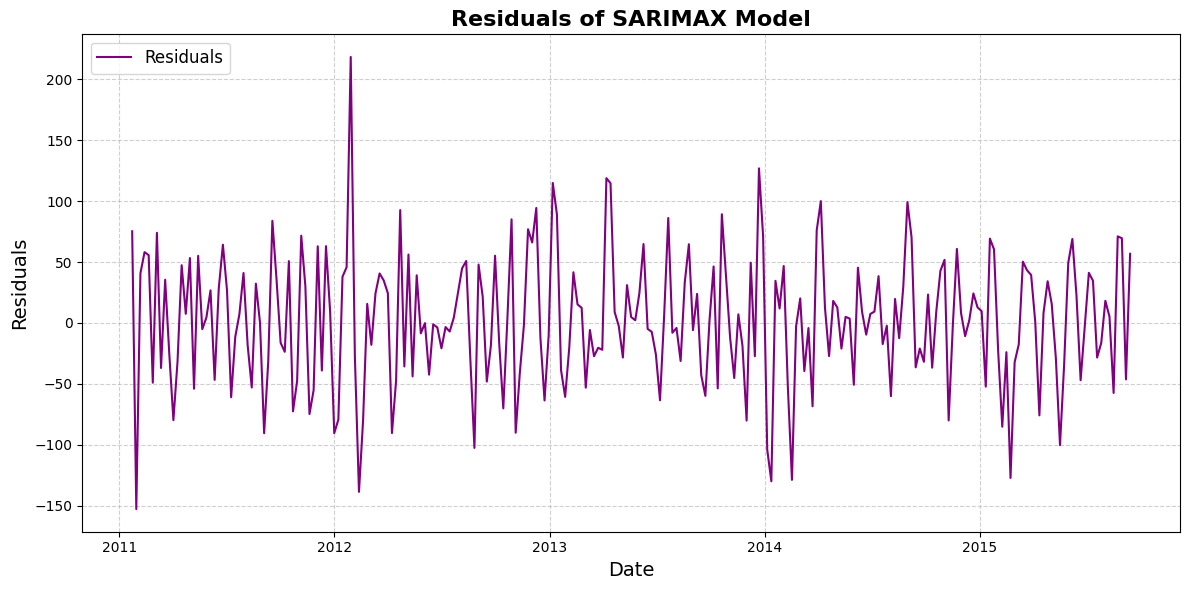

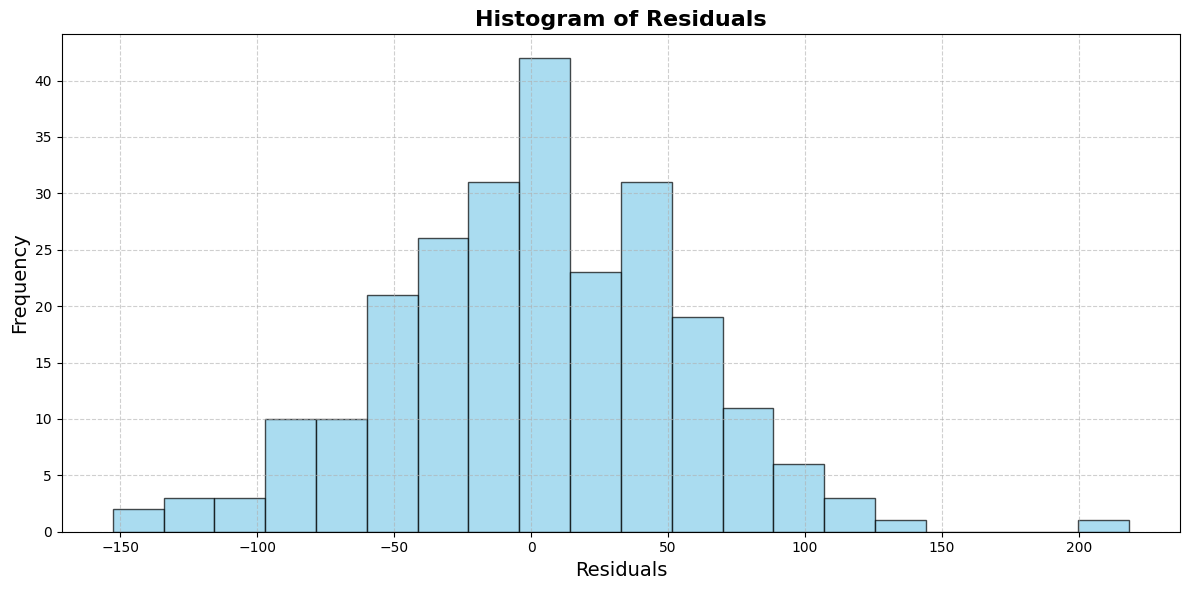

In [31]:
# Analisi dei residui del modello SARIMAX
residuals = model_exog_fit.resid

# Grafico dei residui
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='purple', linewidth=1.5)
plt.title('Residuals of SARIMAX Model', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Istogramma dei residui
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Histogram of Residuals', fontsize=16, fontweight='bold')
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Analisi dei residui del modello SARIMAX con variabili esogene**

1. **Grafico dei residui**

Dall'analisi del grafico emergono tre osservazioni positive:
   - **Media Attorno a Zero**: I residui oscillano costantemente attorno al valore zero, indicando che il modello non soffre di un *bias* sistematico (non tende né a sovrastimare né a sottostimare).
   - **Varianza Costante (Omoschedasticità)**: L'ampiezza delle oscillazioni è ragionevolmente stabile per tutto il periodo, suggerendo che la varianza degli errori è costante.
   - **Assenza di Pattern**: Non sono visibili cicli o schemi prevedibili. Gli errori appaiono casuali, confermando che il modello ha catturato con successo la struttura temporale e l'autocorrelazione presenti nei dati.

2. **Istogramma dei residui**

L'istogramma conferma ulteriormente la bontà del modello:
   - **Forma a Campana**: La distribuzione dei residui ha una chiara e simmetrica forma a campana, molto simile a una distribuzione normale.
   - **Centratura sullo Zero**: Il picco della distribuzione è centrato esattamente sullo zero, rafforzando l'idea che l'errore medio del modello è nullo.

### **Conclusioni**

Questo progetto ha mostrato come l’analisi delle serie temporali dei crimini a Baltimora possa essere notevolmente migliorata introducendo variabili esogene nel modello SARIMAX. Partendo da un SARIMA di base, che catturava solo l’andamento passato, abbiamo osservato che previsioni apparentemente perfette potevano nascondere data leakage, sottolineando l’importanza di selezionare feature rilevanti.

Grazie a un’attenta ingegnerizzazione delle variabili, come il tasso di crimini con arma da fuoco, indicatori stagionali e statistiche delle settimane precedenti, il modello ha ridotto il MAE di oltre il 32%, con residui che si comportano come rumore bianco, confermando la validità statistica.

In sintesi, la precisione delle previsioni dipende più dalla **qualità delle informazioni fornite** che dalla complessità del modello: integrare contesto e pattern recenti ha reso il SARIMAX uno strumento predittivo più accurato e affidabile.